In [3]:
import pandas as pd

df = pd.read_csv('C:/Users/nati/Documents/financial-news-stock-analysis/raw_analyst_ratings.csv')
df.head()



,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [22]:
df['headline_length'] = df['headline'].apply(len)
df['headline_length'].describe()



count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [23]:
df['publisher'].value_counts().head(10)



publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

<Axes: title={'center': 'Headlines per Day'}, xlabel='date'>

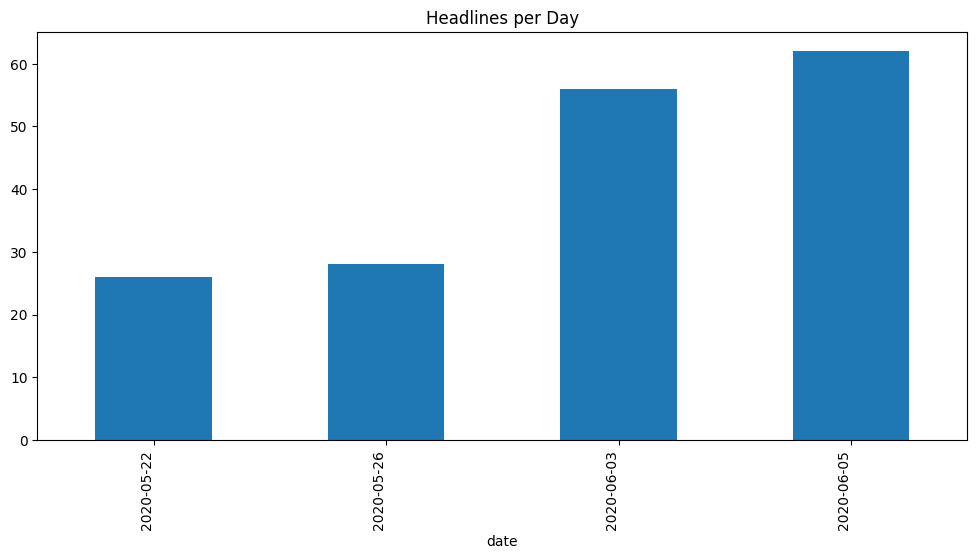

In [29]:


# Convert to datetime (will parse timezone if any)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove timezone info if present
df['date'] = df['date'].apply(lambda x: x.tz_convert(None) if pd.notnull(x) and x.tzinfo is not None else x)

# Now you can safely plot
df['date'].value_counts().sort_index().plot()

df['date'].dt.date.value_counts().sort_index().plot(kind='bar', figsize=(12, 6), title='Headlines per Day')


In [30]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['headline'])
print(vectorizer.get_feature_names_out())


['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


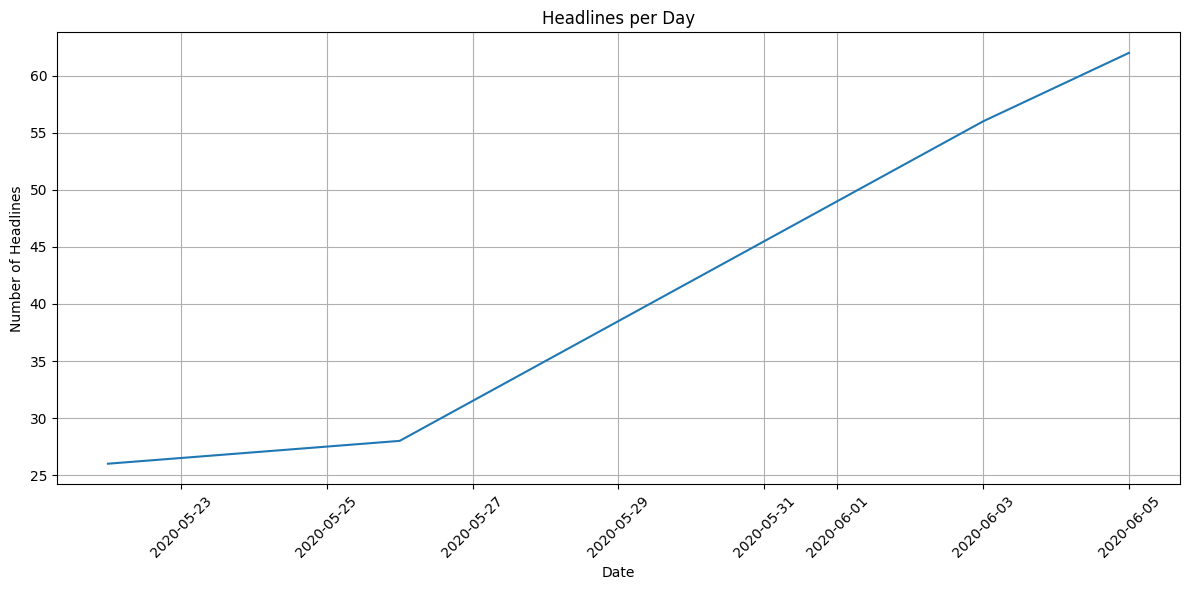

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))  # Wider plot
df.groupby(df['date'].dt.date).size().plot()

plt.title('Headlines per Day')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.tight_layout()  # Adjust layout to prevent clipping
plt.grid(True)
plt.show()



In [39]:
#df['time'] = pd.to_datetime(df['time_column'])  # only if you have a time column
# df['hour'] = df['time'].dt.hour
#df['hour'].value_counts().sort_index().plot(kind='bar')


In [40]:
df['domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in x else x)
df['domain'].value_counts().head(10)


domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

In [36]:
print(df.columns)


Index(['headline', 'url', 'publisher', 'date', 'stock', 'headline_length'], dtype='object')


In [42]:
from textblob import TextBlob

# Apply sentiment polarity
df['sentiment'] = df['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Quick look at sentiment stats
print(df['sentiment'].describe())


count    1.407328e+06
mean     4.905657e-02
std      1.830652e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: sentiment, dtype: float64


<Axes: title={'center': 'Average Sentiment per Day'}, xlabel='date'>

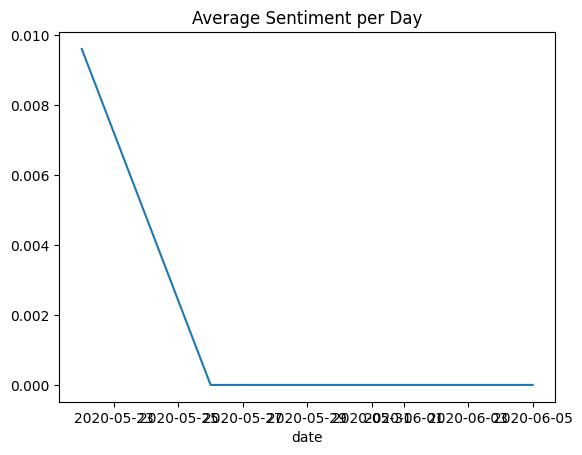

In [43]:
df.groupby(df['date'].dt.date)['sentiment'].mean().plot(title='Average Sentiment per Day')


<Axes: title={'center': 'Average Sentiment by Publisher'}, ylabel='publisher'>

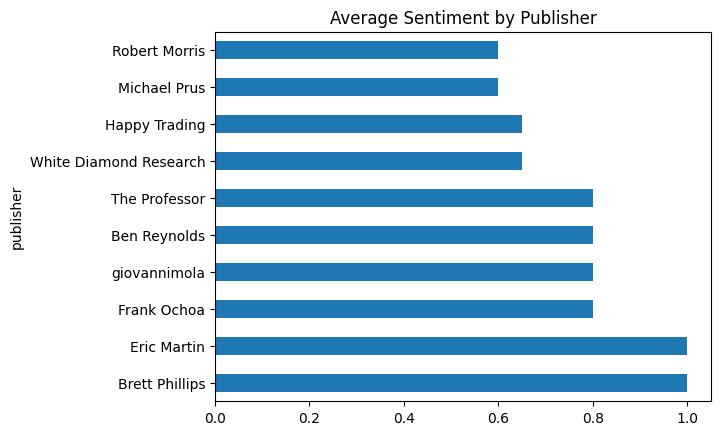

In [44]:
df.groupby('publisher')['sentiment'].mean().sort_values(ascending=False).head(10).plot(kind='barh', title='Average Sentiment by Publisher')
